In [1]:
import sys, os
from typing import Optional
import numpy as np
import pandas as pd
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:", repo_root)
from fixedincomelib import *
print("Fixed Income Library is loaded.")
from matplotlib import pyplot as plt

Added to sys.path: c:\Harsh\NYU\SEM4\FRE-9743\FRE-GT-9743-Assignment-5
Fixed Income Library is loaded.


# Instructions for HW5:

## PCA implementation

### 1. Write PCA algorithm

Please implement a PCA algorithm without using existing PCA api, which means you're only allowed to use Numpy package.

In [2]:
def pca(data_matrix: np.array):
    cov_matrix = np.cov(data_matrix.T)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix) # returns ascending order
    idx = np.argsort(eigen_values)[::-1]
    eigen_values = eigen_values[idx]
    eigen_vectors = eigen_vectors[:, idx]
    return eigen_values, eigen_vectors

def pca_transform(data, eigen_vectors, n):
    return data @ eigen_vectors[:, :n]

def pca_original_basis(scores, eigen_vectors, n):
    return scores @ eigen_vectors[:, :n].T

### 2. Apply PCA

Please download fixed-floating swap rate data from Bloomberg (Ticker: YCSW0490) covering at least six months, with the sample period ending on 2026-02-26.

Although you should download the data for 2026-02-27, exclude that date from the PCA analysis.

The swap tenors should range from 1Y to 30Y.

The dataset should be organized in the format shown below.

After preparing the dataset, apply Principal Component Analysis (PCA) as discussed in class.

![Chart](data_sample.png)

In [3]:
yc = pd.read_excel('yc_data.xlsx', index_col='Dates')
yc.index = pd.to_datetime(yc.index)
print("Fixed floating swap rates")
display(yc)
yc_diff = yc - yc.shift(-1) # Move = Today - Yesterday; days in list are in reverse order
yc_diff.dropna(inplace=True)
mask = yc_diff.eq(0).all(axis=1) # Data also contains trading holidays which result in all zero moves 
yc_diff = yc_diff[~mask]
print("Fixed floating swap rates moves")
display(yc_diff)

Fixed floating swap rates


,12M,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
Dates,,,,,,,,,,,,,,,
2026-02-28,3.4244,3.2086,3.1623,3.1815,3.2240,3.2806,3.3412,3.4017,3.4605,3.5172,3.6234,3.7506,3.8673,3.8953,3.8795
2026-02-27,3.4244,3.2086,3.1623,3.1815,3.2240,3.2806,3.3412,3.4017,3.4605,3.5172,3.6234,3.7506,3.8673,3.8953,3.8795
2026-02-26,3.4528,3.2601,3.2242,3.2491,3.2958,3.3541,3.4157,3.4762,3.5346,3.5915,3.6967,3.8228,3.9376,3.9639,3.9468
2026-02-25,3.4815,3.3031,3.2715,3.2962,3.3426,3.4001,3.4614,3.5209,3.5790,3.6349,3.7388,3.8640,3.9771,4.0020,3.9838
2026-02-24,3.4712,3.2805,3.2407,3.2600,3.3031,3.3610,3.4231,3.4838,3.5423,3.5992,3.7048,3.8312,3.9460,3.9720,3.9545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-05,4.0429,3.8455,3.7962,3.7880,3.7924,3.8020,3.8137,3.8262,3.8401,3.8555,3.8890,3.9283,3.9370,3.8823,3.8049
2025-03-04,4.0390,3.8285,3.7684,3.7565,3.7589,3.7667,3.7772,3.7896,3.8030,3.8182,3.8506,3.8890,3.8971,3.8418,3.7639
2025-03-03,4.0206,3.7981,3.7184,3.6897,3.6813,3.6875,3.6978,3.7106,3.7246,3.7401,3.7738,3.8130,3.8230,3.7687,3.6917


Fixed floating swap rates moves


,12M,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
Dates,,,,,,,,,,,,,,,
2026-02-27,-0.0284,-0.0515,-0.0619,-0.0676,-0.0718,-0.0735,-0.0745,-0.0745,-0.0741,-0.0743,-0.0733,-0.0722,-0.0703,-0.0686,-0.0673
2026-02-26,-0.0287,-0.0430,-0.0473,-0.0471,-0.0468,-0.0460,-0.0457,-0.0447,-0.0444,-0.0434,-0.0421,-0.0412,-0.0395,-0.0381,-0.0370
2026-02-25,0.0103,0.0226,0.0308,0.0362,0.0395,0.0391,0.0383,0.0371,0.0367,0.0357,0.0340,0.0328,0.0311,0.0300,0.0293
2026-02-24,0.0180,0.0266,0.0223,0.0146,0.0092,0.0048,0.0016,-0.0014,-0.0036,-0.0051,-0.0089,-0.0132,-0.0165,-0.0189,-0.0213
2026-02-23,-0.0167,-0.0445,-0.0605,-0.0646,-0.0651,-0.0654,-0.0645,-0.0630,-0.0614,-0.0599,-0.0545,-0.0481,-0.0408,-0.0351,-0.0306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,-0.0544,-0.0510,-0.0420,-0.0316,-0.0237,-0.0172,-0.0119,-0.0079,-0.0051,-0.0024,-0.0001,0.0022,0.0030,0.0035,0.0034
2025-03-05,0.0039,0.0170,0.0278,0.0315,0.0335,0.0353,0.0365,0.0366,0.0371,0.0373,0.0384,0.0393,0.0399,0.0405,0.0410
2025-03-04,0.0184,0.0304,0.0500,0.0668,0.0776,0.0792,0.0794,0.0790,0.0784,0.0781,0.0768,0.0760,0.0741,0.0731,0.0722


In [4]:
eigen_values, eigen_vectors = pca(yc_diff.values)
trace = np.sum(eigen_values)
variance_explained = 100*np.round(np.cumsum(eigen_values/trace),4)
print("Variance Explained [n-factors]: ", variance_explained)

Variance Explained [n-factors]:  [ 91.92  99.02  99.82  99.95  99.98  99.99  99.99 100.   100.   100.
 100.   100.   100.   100.   100.  ]


In [5]:
def plot_top_n(eigen_values, eigen_vectors, n, tenors):
    tenors_int = [int(x[:-1])*(1 if x[-1] == 'M' else 12)//12 for x in tenors]
    for i in range(n):
        plt.plot(tenors_int, eigen_vectors[:,i], label=f"PCA component {i+1} | Eigenvalue: {eigen_values[i]:.4f}")
    plt.legend()
    plt.grid()

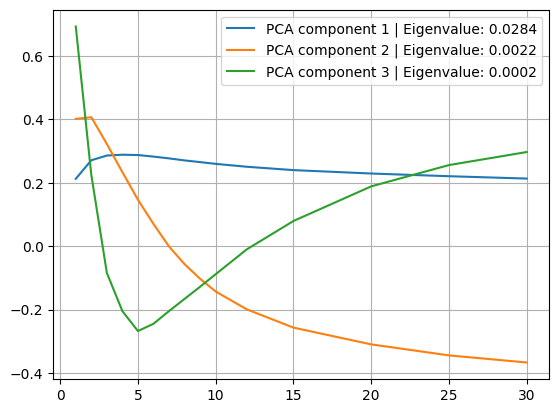

In [6]:
plot_top_n(eigen_values, eigen_vectors, 3, yc_diff.columns)

### 3. Hedging with PCA

With your PCA results, please try to reconstruct the risk profile provided, and present your results.

In [7]:
# read risk_agg.csv
risk_agg = pd.read_csv(os.path.join(repo_root,"risk_agg.csv"))
print("Risk Aggregation Data:")
risk_agg.head()

Risk Aggregation Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,AGG_RISK,2.982972,-1.857554,0.013279,0.071185,13.975129,-5.458591,-0.025772,-7.003277,0.043624,12.783767,-15.256859,-21.13873,-17.444482,0.0,0.0


In [8]:
tenors = ["1Y","2Y","3Y","4Y","5Y","6Y","7Y","8Y","9Y","10Y","12Y","15Y","20Y","25Y","30Y"]

diff_table = pd.DataFrame(index=[f"{i+1} PCs" for i in range(len(tenors))], columns=tenors)
data = risk_agg[tenors].values

for i in range(len(tenors)):
    scores = pca_transform(data, eigen_vectors, i+1)
    reconstructed = pca_original_basis(scores, eigen_vectors, i+1)

    error = data - reconstructed
    diff_table.loc[f"{i+1} PCs"] = error

display(diff_table)

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
1 PCs,4.858792,0.53452,2.5372,2.617708,16.51273,-2.964456,2.418396,-4.615837,2.384151,15.075421,-13.045518,-19.020931,-15.421519,1.947926,1.8823
2 PCs,-0.98716,-5.389085,-2.155285,-0.780758,14.380018,-3.981498,2.434774,-3.788145,3.88427,17.15726,-10.143322,-15.280951,-10.912029,6.96356,7.22315
3 PCs,2.859547,-4.140655,-2.623744,-1.918605,12.894088,-5.339793,1.299141,-4.710372,3.174987,16.667006,-10.198821,-14.840053,-9.864949,8.383471,8.871264
4 PCs,2.124383,-3.634836,-1.982313,-1.568888,12.903982,-5.482641,1.037328,-5.0568,2.771335,16.255921,-10.486039,-14.936678,-9.64518,8.789033,9.37584
5 PCs,-0.507299,2.054219,-1.850967,-3.951642,9.458337,-7.67022,0.397827,-4.297148,4.667446,18.823625,-8.346668,-13.46035,-9.942272,7.44038,7.283622
6 PCs,-0.014392,-0.218346,1.316112,-3.186209,7.722325,-9.042432,-0.198458,-4.222256,5.157632,19.420046,-7.447698,-13.002831,-10.17202,6.956536,7.077288
7 PCs,0.067225,-0.520568,1.721837,-3.285354,7.520141,-8.981534,-0.123643,-4.222315,4.95736,19.400818,-8.072991,-13.981856,-6.594894,9.09528,3.115731
8 PCs,0.098439,-0.366069,-0.771686,1.210633,7.49494,-10.091315,-1.995487,-5.565864,5.313738,19.490146,-6.806358,-12.751833,-6.113513,8.618583,2.340547
9 PCs,0.134263,-0.60833,0.429004,-0.175263,4.55157,-3.67116,1.917043,-6.619447,-7.322855,15.058195,-3.968319,1.849116,-4.646399,4.551678,-1.426607
10 PCs,0.13312,-0.544371,0.140545,0.414075,3.614463,-3.713328,2.640221,-5.957495,-7.598459,15.012333,-4.285368,1.562781,-4.90964,4.880053,-1.34043


Using the provided hedging instruments, solve for the optimal portfolio weights that hedge the aggregated DV01 risk profile. 

Compare the eigenspace approach against direct least squares, and argue mathematically why the former is preferred.

In [9]:
hedging = pd.read_csv(os.path.join(repo_root,"hedging_instruments.csv"))
print("Hedging Instruments Data:")
hedging.head()

Hedging Instruments Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,1Y1Y,0.990383,-1.905780,-0.040437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,1Y5Y,0.986415,0.006578,0.000573,0.001714,0.049129,-5.468511,-0.035436,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,5Y5Y,0.002970,0.005982,0.009149,0.012336,4.626952,-0.016352,-0.019360,-0.022309,-0.025584,-8.501197,0.000000,0.000000,0.000000,0.0,0.0
3,10Y10Y,0.003699,0.007465,0.011399,0.015366,0.019642,0.023980,0.028543,0.032885,0.037736,8.499983,-0.093768,-0.198309,-14.335121,0.0,0.0


Method 1: Eigenspace-approach

In [10]:
hedging_pca = pca_transform(hedging[tenors].values,eigen_vectors, 4) # 4x4
risk_pca = pca_transform(risk_agg[tenors].values, eigen_vectors, 4) # 1x4
# optimal_hedges_pca [1x4] * hedging_pca [4x4] + risk_pca [4x4] = 0
optimal_hedges_pca = -risk_pca @ np.linalg.inv(hedging_pca)
unhedged_risk_pca = risk_agg[tenors].values + optimal_hedges_pca@hedging[tenors].values

Method 2: LS-approach

In [11]:
optimal_hedges_ls, _, _, _ = np.linalg.lstsq(hedging[tenors].values.T, -risk_agg[tenors].values.T)
unhedged_risk_ls = risk_agg[tenors].values + optimal_hedges_ls.T@hedging[tenors].values

Comparison

In [12]:
hedging_instruments = hedging["Unnamed: 0"].values

weights_df = pd.DataFrame({
    "Instrument": hedging_instruments,
    "PCA_Weight": optimal_hedges_pca.flatten(),
    "LS_Weight": optimal_hedges_ls.flatten()
})

display(weights_df)

,Instrument,PCA_Weight,LS_Weight
0,1Y1Y,-0.902777,-1.193592
1,1Y5Y,-1.952868,-1.045629
2,5Y5Y,-3.892630,-0.674989
3,10Y10Y,-2.256059,-1.487148


In [13]:
risk_df = pd.DataFrame(
    np.vstack([
        risk_agg[tenors].values,
        unhedged_risk_pca,
        unhedged_risk_ls
    ]),
    columns=tenors,
    index=["Original Risk", "Residual Risk (PCA)", "Residual Risk (LS)"]
)

display(risk_df)

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
Original Risk,2.982972,-1.857554,0.013279,0.071185,13.975129,-5.458591,-0.025772,-7.003277,0.043624,12.783767,-15.256859,-21.138730,-17.444482,0.0,0.0
Residual Risk (PCA),0.142632,-0.190032,-0.012664,-0.014849,-4.176138,5.230238,0.054394,-6.990626,0.058079,26.699313,-15.045313,-20.691332,14.896397,0.0,0.0
Residual Risk (LS),0.761929,0.395152,0.037818,0.038214,10.771407,0.234816,-0.018100,-7.037124,0.004774,5.881243,-15.117412,-20.843814,3.873965,0.0,0.0


The PCA hedge is preferred over direct least squares because it transforms the highly correlated tenor risks into a set of orthogonal principal components, capturing the main drivers of the yield curve i.e. level, slope, and curvature. By focusing only on the first few dominant components, the PCA approach reduces dimensionality, filters out noise from small eigenvalues, and produces numerically stable hedge weights. In contrast, direct least squares tries to hedge all tenor exposures, including noisy and nearly collinear ones, which can lead to unstable and extreme weights. As a result, PCA hedging not only yields more robust and interpretable weights but also effectively neutralizes the economically meaningful risks of the curve.